<a href="https://colab.research.google.com/github/salih-salu/Speech_Emotion_Recognition_using_AudioFiles/blob/main/Speech_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import os
import glob

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape, LSTM

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.callbacks import ModelCheckpoint

#Get the Dataset through google drive mounting

In [ ]:
Dataset_path = '/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset'
print(os.listdir(Dataset_path))

['train_set', 'test_set']


In [ ]:
train_path = os.path.join(Dataset_path, 'train_set')
test_path = os.path.join(Dataset_path, 'test_set')

print(os.listdir(train_path))
print(os.listdir(test_path))

['Actor_18', 'Actor_14', 'Actor_17', 'Actor_19', 'Actor_16', 'Actor_15', 'Actor_12', 'Actor_11', 'Actor_10', 'Actor_08', 'Actor_05', 'Actor_09', 'Actor_06', 'Actor_04', 'Actor_07', 'Actor_13', 'Actor_03', 'Actor_01', 'Actor_02']
['Actor_22', 'Actor_24', 'Actor_23', 'Actor_20', 'Actor_21']


#Used glob to find all audio files from the dataset

In [ ]:
train_files = glob.glob(
    train_path + '/**/*.wav',
    recursive=True
)

test_files = glob.glob(
    test_path + '/**/*.wav',
    recursive=True
)

In [ ]:
print(len(train_files), len(test_files))

1140 300


In [ ]:
emotion_labels = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [ ]:
def get_emotion(file_path):
    filename = os.path.basename(file_path)
    emotion_code = filename.split("-")[2]
    return emotion_labels[emotion_code]

In [ ]:
#test emotion label using sample file from train_file

print(train_files[0])
print(get_emotion(train_files[0]))

#test emotion label using sample file from test_file

print(test_files[1])
print(get_emotion(test_files[1]))

/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset/train_set/Actor_18/03-01-03-01-01-01-18.wav
happy
/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset/test_set/Actor_22/03-01-06-02-01-01-22.wav
fearful


#Just create the DataFrame with Audio files paths and its related labels

In [ ]:
train_df = pd.DataFrame({
    'file_path': train_files
})

test_df = pd.DataFrame({
    'file_path': test_files
})

In [ ]:
# train_df

In [ ]:
train_df['emotion'] = train_df['file_path'].apply(get_emotion)

In [ ]:
train_df

,file_path,emotion
0,/content/drive/MyDrive/Speech_Emotion_Recognit...,happy
1,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
2,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
3,/content/drive/MyDrive/Speech_Emotion_Recognit...,sad
4,/content/drive/MyDrive/Speech_Emotion_Recognit...,neutral
...,...,...
1135,/content/drive/MyDrive/Speech_Emotion_Recognit...,surprised
1136,/content/drive/MyDrive/Speech_Emotion_Recognit...,disgust
1137,/content/drive/MyDrive/Speech_Emotion_Recognit...,surprised
1138,/content/drive/MyDrive/Speech_Emotion_Recognit...,disgust


In [ ]:
test_df["emotion"] = test_df["file_path"].apply(get_emotion)

In [ ]:
test_df

,file_path,emotion
0,/content/drive/MyDrive/Speech_Emotion_Recognit...,neutral
1,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
2,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
3,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
4,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
...,...,...
295,/content/drive/MyDrive/Speech_Emotion_Recognit...,fearful
296,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
297,/content/drive/MyDrive/Speech_Emotion_Recognit...,calm
298,/content/drive/MyDrive/Speech_Emotion_Recognit...,surprised


In [ ]:
print(train_df["emotion"].value_counts())

emotion
happy        152
calm         152
sad          152
fearful      152
surprised    152
angry        152
disgust      152
neutral       76
Name: count, dtype: int64


In [ ]:
print(test_df["emotion"].value_counts())

emotion
fearful      40
sad          40
calm         40
angry        40
happy        40
disgust      40
surprised    40
neutral      20
Name: count, dtype: int64


#Audio processing

taken one sample audio for visualize the audio wave

In [ ]:
file_path = train_df.iloc[0]["file_path"]
print(file_path)

audio, sample_rate = librosa.load(
    file_path,
    sr=16000
)

print("Sample rate:", sample_rate)
print("Audio length:", len(audio))

/content/drive/MyDrive/Speech_Emotion_Recognition/Speech_emo_dataset/train_set/Actor_18/03-01-03-01-01-01-18.wav
Sample rate: 16000
Audio length: 54455


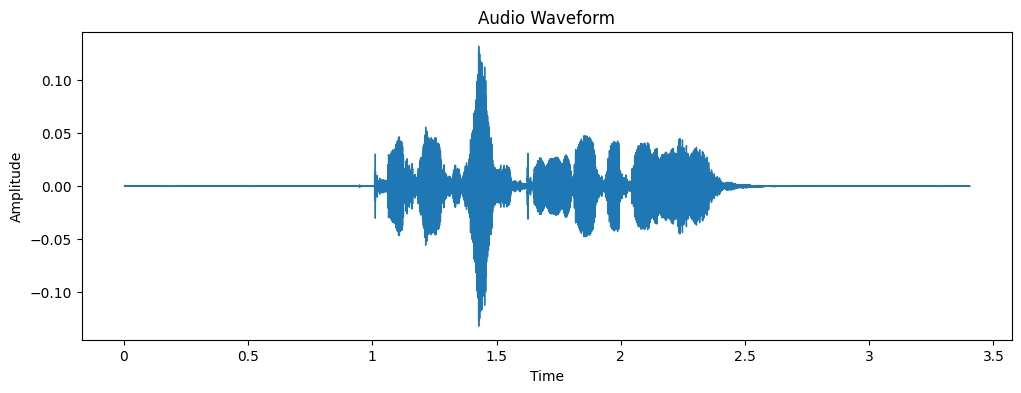

In [ ]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    audio,
    sr=sample_rate
)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print(mfcc.shape)

(40, 107)


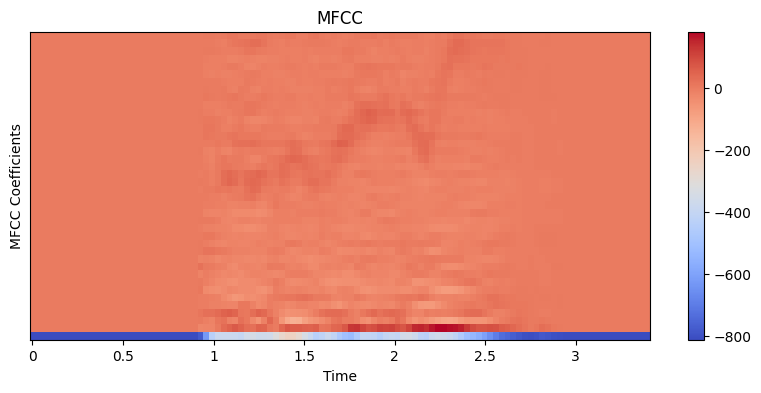

In [ ]:
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sample_rate
)

plt.colorbar()
plt.title("MFCC")
plt.ylabel("MFCC Coefficients")
plt.xlabel("Time")
plt.show()

#MFCC Extraction for all audio files

Mel Frequency Cepstral Coefficients

In [ ]:
def extract_mfcc(file_path, n_mfcc=40, max_pad_len=174):
    audio, sample_rate = librosa.load(
        file_path,
        sr=16000
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=n_mfcc
    )

    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(
            mfcc,
            pad_width=((0, 0), (0, pad_width)),
            mode='constant'
        )
    else:
        mfcc = mfcc[:, :max_pad_len]

    return mfcc

Create X_train and y_train

In [ ]:
X_train = []
y_train = []

for file_path in train_df["file_path"]:
    # print(file_path)
    mfcc = extract_mfcc(file_path)

    X_train.append(mfcc)

    emotion = get_emotion(file_path)
    y_train.append(emotion)

Converting (X_train and y_train) List to array

In [ ]:
X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1140, 40, 174)
y_train shape: (1140,)


Create X_test and y_test

In [ ]:
X_test = []
y_test = []

for file_path in test_df["file_path"]:

    mfcc = extract_mfcc(file_path)

    X_test.append(mfcc)

    emotion = get_emotion(file_path)
    y_test.append(emotion)

In [ ]:
X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (300, 40, 174)
y_test shape: (300,)


#Converting the emotion labels (output) to numbers using LabelEncoding

In [ ]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

print(encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [ ]:
print(y_train)

[4 1 1 ... 7 2 7]


In [ ]:
# print(y_test)

#Add CNN channel dimension

In [ ]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_test.shape)

(1140, 40, 174, 1)
(300, 40, 174, 1)


In [ ]:
# print(X_train)

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(40, 174, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
# model.add(Flatten())
model.add(Reshape((-1, 128)))
model.add(LSTM(128))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='softmax'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076,872 (4.11 MB)

 Trainable params: 1,076,872 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Apply check point to save the best model

In [ ]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
model.fit(X_train, y_train, batch_size=32, epochs=30, callbacks=[checkpoint])

Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.1329 - loss: 6.9837
Epoch 1: accuracy improved from None to 0.16140, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 354ms/step - accuracy: 0.1614 - loss: 3.7251
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.2331 - loss: 1.9371
Epoch 2: accuracy improved from 0.16140 to 0.24737, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 396ms/step - accuracy: 0.2474 - loss: 1.9205
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.2722 - loss: 1.8280
Epoch 3: accuracy improved from 0.24737 to 0.27632, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 406ms/step - accuracy: 0.2763 - loss: 1.8341
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.3055 - loss: 1.7374
Epoch 4: accuracy im

In [ ]:
# model.history.history

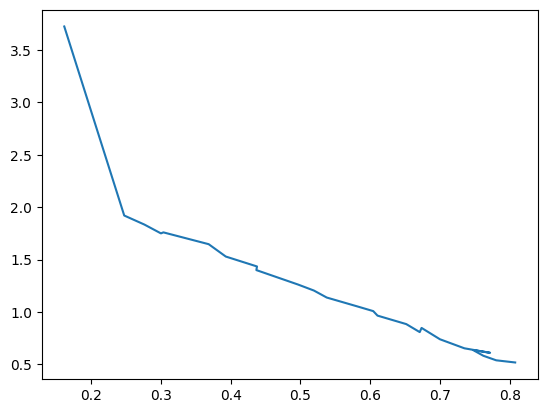

In [ ]:
plt.plot(model.history.history['accuracy'], model.history.history['loss'])

#evaluate the model performance

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_loss, test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5067 - loss: 3.2239
3.2239067554473877 0.5066666603088379


In [ ]:
y_pred = model.predict(X_test)
# for i in y_pred:
#   print(i)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


In [ ]:
y_pred_ind = y_pred.argmax(axis=1)
y_pred_ind

array([7, 3, 3, 4, 4, 6, 1, 2, 6, 1, 2, 1, 6, 6, 2, 0, 1, 3, 3, 3, 2, 6,
       1, 3, 0, 4, 5, 4, 0, 4, 1, 1, 3, 1, 5, 7, 6, 2, 6, 1, 0, 0, 7, 0,
       2, 0, 6, 0, 0, 2, 2, 2, 7, 4, 7, 7, 4, 7, 7, 7, 1, 1, 6, 4, 1, 1,
       0, 4, 2, 1, 1, 0, 3, 4, 2, 1, 5, 0, 1, 1, 1, 0, 7, 1, 1, 1, 0, 6,
       2, 1, 0, 6, 0, 4, 2, 5, 1, 0, 0, 2, 0, 0, 6, 4, 7, 1, 7, 2, 2, 7,
       7, 7, 0, 7, 2, 2, 7, 7, 2, 2, 1, 7, 2, 7, 7, 7, 2, 7, 7, 2, 7, 1,
       4, 2, 7, 2, 4, 7, 2, 5, 7, 4, 7, 7, 1, 7, 2, 4, 1, 1, 7, 6, 2, 1,
       2, 1, 4, 7, 2, 2, 4, 7, 7, 7, 1, 7, 0, 7, 3, 1, 7, 7, 7, 7, 7, 7,
       2, 7, 7, 7, 1, 1, 6, 1, 6, 1, 1, 1, 4, 1, 5, 7, 7, 7, 2, 4, 4, 2,
       0, 7, 4, 2, 4, 7, 0, 7, 6, 4, 6, 6, 7, 6, 2, 2, 3, 1, 2, 7, 2, 4,
       6, 2, 7, 7, 6, 7, 3, 0, 7, 7, 6, 3, 7, 5, 2, 0, 4, 6, 0, 7, 0, 0,
       2, 1, 2, 1, 5, 0, 0, 0, 0, 0, 0, 0, 0, 2, 7, 0, 0, 1, 0, 0, 2, 0,
       0, 7, 0, 0, 7, 1, 2, 7, 0, 7, 7, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 1, 2, 0, 2, 1, 0, 2, 2, 1, 7, 7])

#Classification Report

In [ ]:
crp = classification_report(y_test, y_pred_ind)
print(crp)

              precision    recall  f1-score   support

           0       0.45      0.65      0.53        40
           1       0.63      0.78      0.70        40
           2       0.50      0.68      0.57        40
           3       0.58      0.17      0.27        40
           4       0.35      0.23      0.27        40
           5       0.62      0.25      0.36        20
           6       0.48      0.28      0.35        40
           7       0.51      0.90      0.65        40

    accuracy                           0.51       300
   macro avg       0.52      0.49      0.46       300
weighted avg       0.51      0.51      0.47       300



In [ ]:
print(len(y_test), len(y_pred_ind))

300 300


In [ ]:
print("Actual:   ", y_test[150])
print("Predicted: ", y_pred_ind[150])

Actual:    3
Predicted:  7


#Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred_ind)
print('Accuracy: ', accuracy)

Accuracy:  0.5066666666666667


# Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_ind)
print(cm)

[[26  0  2  0  2  0  0 10]
 [ 1 31  4  0  0  1  3  0]
 [ 9  0 27  0  1  0  0  3]
 [ 6  1  6  7 10  0  5  5]
 [ 9  1  3  3  9  1  3 11]
 [ 2  6  2  0  1  5  1  3]
 [ 4 10 10  1  1  1 11  2]
 [ 1  0  0  1  2  0  0 36]]


In [ ]:
labels = list(emotion_labels.values())
print(labels)

['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


#Confusion Matrix Display

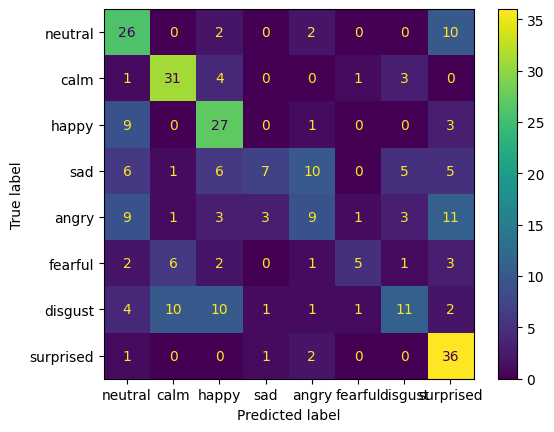

In [ ]:
cmd = ConfusionMatrixDisplay(cm,display_labels=labels)
cmd.plot()

#Test an audio file via uploading.

In [ ]:
# from google.colab import files

# uploaded = files.upload()

In [ ]:
# def extract_mfcc_for_prediction(file_path, n_mfcc=40, max_pad_len=174):
#     audio, sample_rate = librosa.load(
#         file_path,
#         sr=16000
#     )
#     mfcc = librosa.feature.mfcc(
#         y=audio,
#         sr=sample_rate,
#         n_mfcc=n_mfcc
#     )

#     if mfcc.shape[1] < max_pad_len:
#         pad_width = max_pad_len - mfcc.shape[1]
#         mfcc = np.pad(
#             mfcc,
#             ((0, 0), (0, pad_width)),
#             mode='constant'
#         )
#     else:
#         mfcc = mfcc[:, :max_pad_len]

#     return mfcc

In [ ]:
# # file_path = list(uploaded.keys())[0]
# file_path = '/content/03-01-08-02-02-01-21.wav'

# mfcc = extract_mfcc_for_prediction(file_path)
# mfcc = mfcc[np.newaxis, ..., np.newaxis]
# prediction = model.predict(mfcc)
# predicted_class = np.argmax(prediction, axis=1)[0]

# predicted_emotion = encoder.inverse_transform([predicted_class])[0]
# confidence = np.max(prediction) * 100

# print("Predicted Emotion:", predicted_emotion)
# print("Confidence:", round(confidence, 2), "%")

In [ ]:
# The above prediction is correct for the uploaded audio file.